# NIW Conjugate Prior vs. Separate Priors Comparison

This notebook demonstrates the difference between Normal-Inverse-Wishart (NIW) conjugate priors and separate independent priors for means and covariances in Gaussian Mixture Models.

We will create a modified version of the GMM class to force separate prior updates, allowing us to compare the two approaches side by side.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sys
import os

# Add the parent directory FIRST to import tgmm from local repo
parent_dir = os.path.abspath('..')
if parent_dir in sys.path:
    sys.path.remove(parent_dir)
sys.path.insert(0, parent_dir)

from tgmm import GaussianMixture
from tgmm.plotting import plot_gmm, dynamic_figsize

# Verify we're using the local version
import tgmm
print(f"Using tgmm from: {tgmm.__file__}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using tgmm from: /home/asp/Downloads/HeaDS/tgmm/tgmm/__init__.py
Using device: cpu


## Normal-Inverse-Wishart (NIW) Conjugate Prior Mathematical Background

The Normal-Inverse-Wishart (NIW) prior is a **conjugate prior** for the parameters of a multivariate Gaussian distribution when both the mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ are unknown. This is fundamentally different from specifying separate priors for means and covariances.

### Mathematical Formulation

For a multivariate Gaussian component with parameters $(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, the NIW prior is defined as:

$$p(\boldsymbol{\mu}, \boldsymbol{\Sigma}^{-1}) = \mathcal{N}(\boldsymbol{\mu} | \boldsymbol{m}_0, (\lambda_0 \boldsymbol{\Sigma})^{-1}) \cdot \mathcal{W}(\boldsymbol{\Sigma}^{-1} | \nu_0, \boldsymbol{\Psi}_0^{-1})$$

Where:
- $\boldsymbol{m}_0$: prior mean (hyperparameter)
- $\lambda_0$: prior precision parameter (controls how tightly the mean is constrained around $\boldsymbol{m}_0$)
- $\nu_0$: degrees of freedom for the Wishart distribution
- $\boldsymbol{\Psi}_0$: scale matrix for the Wishart distribution

### Key Properties of NIW Prior

1. **Conjugacy**: The posterior distribution is also NIW, making Bayesian inference analytically tractable.

2. **Coupling**: The mean and covariance are coupled through the precision parameter $\lambda_0$. When $\boldsymbol{\Sigma}$ is large (uncertain), the mean prior becomes less informative automatically.

3. **Natural Parameterization**: The NIW prior naturally captures the relationship between mean uncertainty and covariance uncertainty.

### NIW Posterior Updates

Given data points assigned to component $k$, the NIW posterior parameters are:

$$\lambda_n = \lambda_0 + n_k$$

$$\nu_n = \nu_0 + n_k$$

$$\boldsymbol{m}_n = \frac{\lambda_0 \boldsymbol{m}_0 + n_k \bar{\boldsymbol{x}}_k}{\lambda_0 + n_k}$$

$$\boldsymbol{\Psi}_n = \boldsymbol{\Psi}_0 + \mathbf{S}_k + \frac{\lambda_0 n_k}{\lambda_0 + n_k}(\bar{\boldsymbol{x}}_k - \boldsymbol{m}_0)(\bar{\boldsymbol{x}}_k - \boldsymbol{m}_0)^T$$

where $\mathbf{S}_k$ is the scatter matrix for component $k$.

### Why NIW ≠ Separate Mean + Covariance Priors

When using **separate priors**:
- Mean prior: $p(\boldsymbol{\mu}) = \mathcal{N}(\boldsymbol{\mu} | \boldsymbol{m}_0, \tau_0^2 \mathbf{I})$
- Covariance prior: $p(\boldsymbol{\Sigma}^{-1}) = \mathcal{W}(\boldsymbol{\Sigma}^{-1} | \nu_0, \boldsymbol{\Psi}_0^{-1})$

## Generate Synthetic Data

We'll create synthetic 2D data with three well-separated Gaussian components to clearly observe the differences between the two approaches.

Generated 400 samples with 2 features
Data shape: (400, 2)
Data range: X1=[-4.31, 3.58], X2=[-3.91, 3.66]


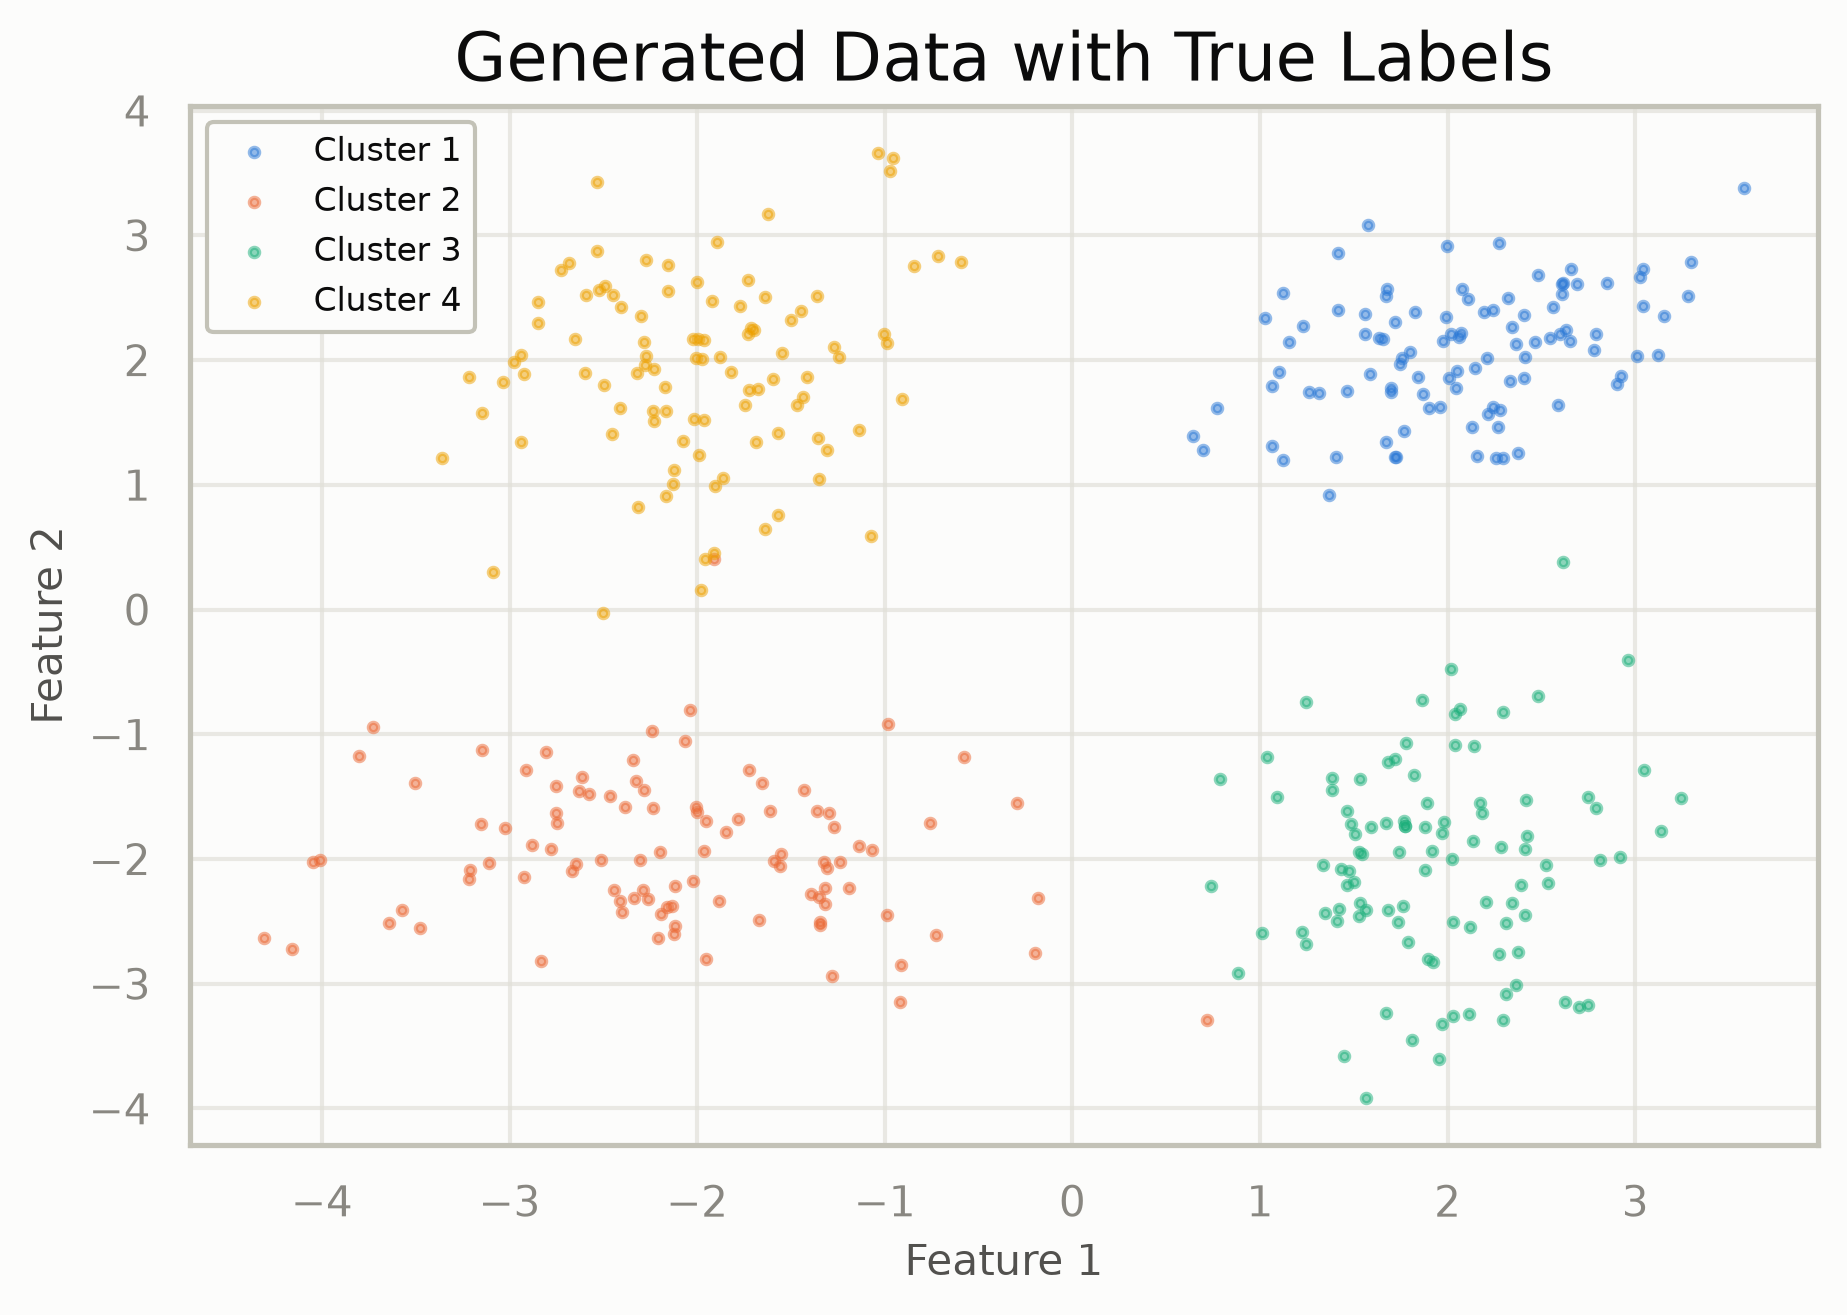

In [2]:
# Create synthetic 2D data with clear structure
n_samples_per_component = 100
true_means = np.array([
    [2.0, 2.0], 
    [-2.0, -2.0], 
    [2.0, -2.0],
    [-2.0, 2.0]
])
true_covs = np.array([
    [[0.5, 0.2], [0.2, 0.3]],
    [[0.8, -0.1], [-0.1, 0.4]], 
    [[0.3, 0.0], [0.0, 0.6]],
    [[0.4, 0.1], [0.1, 0.5]]
])

# Generate data
X_list = []
colors = ['red', 'blue', 'green']
for i, (mean, cov) in enumerate(zip(true_means, true_covs)):
    X_component = np.random.multivariate_normal(mean, cov, n_samples_per_component)
    X_list.append(X_component)

X = np.vstack(X_list)
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
n_samples, n_features = X.shape
n_components = 4

# Plot the generated data
plt.figure()
plot_gmm(X_tensor.cpu().numpy(), true_labels=np.repeat(np.arange(n_components), n_samples_per_component), title="Generated Data with True Labels")

print(f"Generated {n_samples} samples with {n_features} features")
print(f"Data shape: {X.shape}")
print(f"Data range: X1=[{X[:, 0].min():.2f}, {X[:, 0].max():.2f}], X2=[{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")

## Define Prior Hyperparameters

We'll set up the same prior hyperparameters for both approaches to ensure a fair comparison.

In [3]:
# Define NIW hyperparameters
lambda0 = 20  # Prior precision parameter - moderate coupling
nu0 = n_features + 100  # Degrees of freedom (weak prior)
m0 = torch.zeros(n_components, n_features, device=device)  # Prior mean at origin

# Scale matrix (we expect unit covariances)
Psi0 = torch.eye(n_features, device=device).unsqueeze(0).expand(n_components, -1, -1) * 100.0

print("Prior Hyperparameters:")
print(f"λ₀ (precision parameter): {lambda0}")
print(f"ν₀ (degrees of freedom): {nu0}")
print(f"m₀ (prior mean): {m0[0].cpu().numpy()}")
print(f"Ψ₀ (scale matrix): \n{Psi0[0].cpu().numpy()}")
print(f"\nNote: All three components use the same prior hyperparameters")

Prior Hyperparameters:
λ₀ (precision parameter): 20
ν₀ (degrees of freedom): 102
m₀ (prior mean): [0. 0.]
Ψ₀ (scale matrix): 
[[100.   0.]
 [  0. 100.]]

Note: All three components use the same prior hyperparameters


## Comparison: Different Prior Configurations

Now we'll fit the same data using three different configurations:
1. **Mean Prior Only**: Prior on means, MLE for covariances
2. **Covariance Prior Only**: Prior on covariances, MLE for means  
3. **NIW Conjugate Prior**: Coupled prior on both parameters

This will demonstrate how priors affect the fitted parameters.

Fitting Mean Prior Only...
Fitting Covariance Prior Only...


Fitting NIW Conjugate Prior...


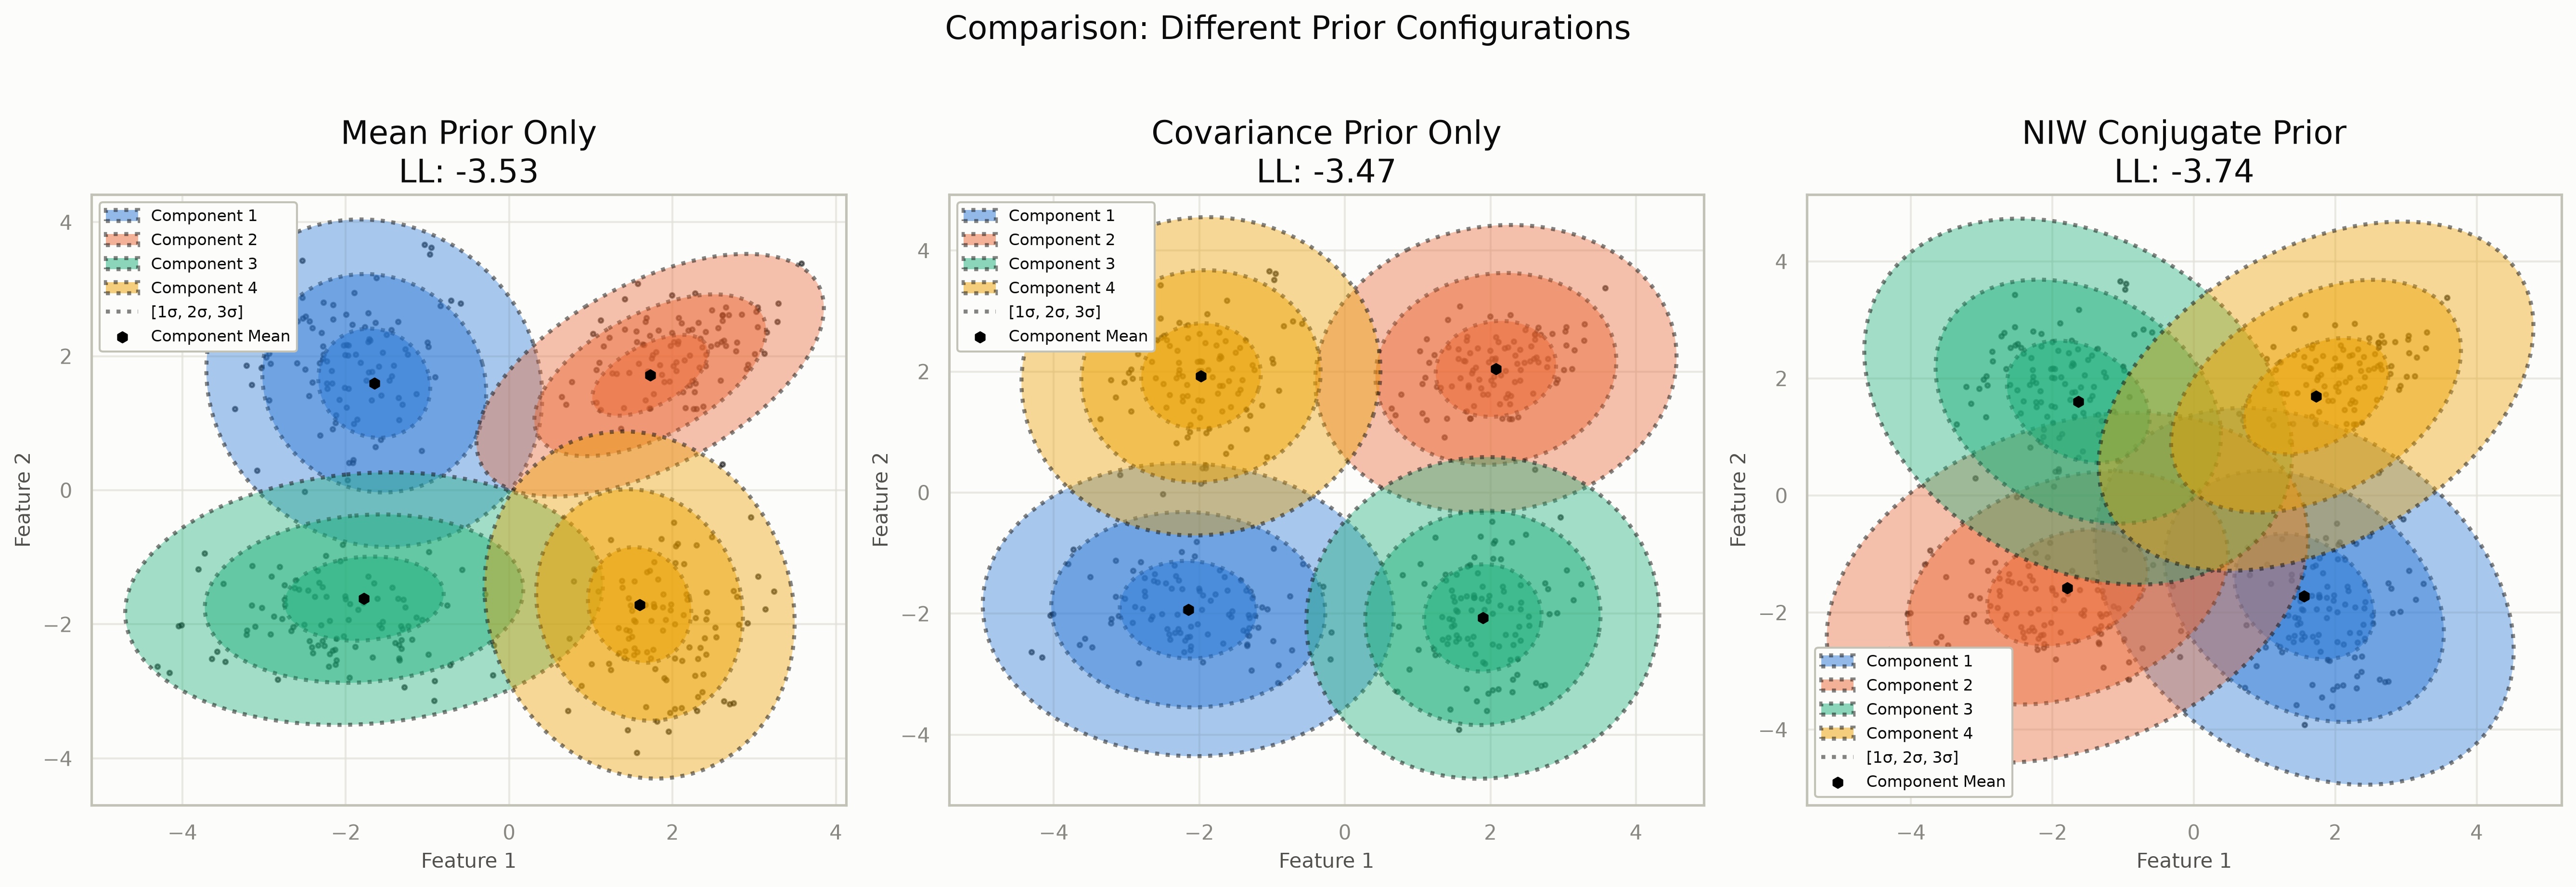

In [4]:
# Set up the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparison: Different Prior Configurations", fontsize=16, y=1.02)

models = {}

# 1. Mean Prior Only
print("Fitting Mean Prior Only...")
ax = axes[0]
models['mean_only'] = GaussianMixture(
    n_features=n_features,
    n_components=n_components,
    covariance_type='full',
    max_iter=1000,
    device=device,
    mean_prior=m0,
    mean_precision_prior=lambda0,
)
models['mean_only'].fit(X_tensor)

plot_gmm(
    X=X,
    gmm=models['mean_only'],
    ax=ax,
    title=f"Mean Prior Only\nLL: {models['mean_only'].lower_bound_:.2f}",
)

# 2. Covariance Prior Only
print("Fitting Covariance Prior Only...")
ax = axes[1]
models['cov_only'] = GaussianMixture(
    n_features=n_features,
    n_components=n_components,
    covariance_type='full',
    max_iter=1000,
    device=device,
    covariance_prior=Psi0,
    degrees_of_freedom_prior=nu0,
)
models['cov_only'].fit(X_tensor)

plot_gmm(
    X=X,
    gmm=models['cov_only'],
    ax=ax,
    title=f"Covariance Prior Only\nLL: {models['cov_only'].lower_bound_:.2f}",
)

# 3. NIW Conjugate Prior
print("Fitting NIW Conjugate Prior...")
ax = axes[2]
models['niw'] = GaussianMixture(
    n_features=n_features,
    n_components=n_components,
    covariance_type='full',
    max_iter=1000,
    device=device,
    mean_prior=m0,
    mean_precision_prior=lambda0,
    covariance_prior=Psi0,
    degrees_of_freedom_prior=nu0,
)
models['niw'].fit(X_tensor)

plot_gmm(
    X=X,
    gmm=models['niw'],
    ax=ax,
    title=f"NIW Conjugate Prior\nLL: {models['niw'].lower_bound_:.2f}",
)

plt.tight_layout()
plt.show()


In [5]:
def analyze_niw_hyperparameters(X_tensor, n_components, n_features, device, title_suffix=""):
    """Run NIW hyperparameter sensitivity analysis on given data.
    
    Args:
        X_tensor: Input data tensor
        n_components: Number of mixture components
        n_features: Number of features
        device: torch device
        title_suffix: Additional text for plot title
    """
    # Define parameter grids
    lambda_grid = [0.1, 1.0, 10.0, 100.0, 1000]
    nu_grid = [n_features, 10, 50, 100, 500, 1000]
    psi_grid = [
        torch.eye(n_features, device=device).unsqueeze(0).expand(n_components, -1, -1) * scale
        for scale in [0.1, 1.0, 10.0, 100.0, 1000.0]
    ]
    m0_grid = [
        torch.zeros(n_components, n_features, device=device),  # Zeros
        torch.tensor([[2.0, 2.0], [-2.0, -2.0], [2.0, -2.0], [-2.0, 2.0]], device=device),  # ±2
        torch.tensor([[4.0, 4.0], [-4.0, -4.0], [4.0, -4.0], [-4.0, 4.0]], device=device),  # ±4
        torch.tensor([[8.0, 8.0], [-8.0, -8.0], [8.0, -8.0], [-8.0, 8.0]], device=device),  # ±8
        torch.tensor([[16.0, 16.0], [-16.0, -16.0], [16.0, -16.0], [-16.0, 16.0]], device=device),  # ±16
    ]
    
    # Default values
    lambda_default = 1.0
    nu_default = n_features + 10
    m0_default = torch.zeros(n_components, n_features, device=device)
    psi_default = torch.eye(n_features, device=device).unsqueeze(0).expand(n_components, -1, -1) * 1.0
    
    # Define all 6 parameter combinations
    param_combinations = [
        {'x': 'nu', 'y': 'lambda', 'x_grid': nu_grid, 'y_grid': lambda_grid, 
         'x_label': 'ν₀ (Degrees of Freedom)', 'y_label': 'λ₀ (Coupling Parameter)',
         'fixed': {'m0': m0_default, 'psi': psi_default}},
        
        {'x': 'psi', 'y': 'lambda', 'x_grid': list(range(len(psi_grid))), 'y_grid': lambda_grid,
         'x_label': 'Ψ₀ Scale', 'y_label': 'λ₀ (Coupling Parameter)',
         'fixed': {'nu': nu_default, 'm0': m0_default}},
        
        {'x': 'm0', 'y': 'lambda', 'x_grid': list(range(len(m0_grid))), 'y_grid': lambda_grid,
         'x_label': 'm₀ Configuration', 'y_label': 'λ₀ (Coupling Parameter)',
         'fixed': {'nu': nu_default, 'psi': psi_default}},
        
        {'x': 'psi', 'y': 'nu', 'x_grid': list(range(len(psi_grid))), 'y_grid': nu_grid,
         'x_label': 'Ψ₀ Scale', 'y_label': 'ν₀ (Degrees of Freedom)',
         'fixed': {'lambda': lambda_default, 'm0': m0_default}},
        
        {'x': 'm0', 'y': 'nu', 'x_grid': list(range(len(m0_grid))), 'y_grid': nu_grid,
         'x_label': 'm₀ Configuration', 'y_label': 'ν₀ (Degrees of Freedom)',
         'fixed': {'lambda': lambda_default, 'psi': psi_default}},
        
        {'x': 'm0', 'y': 'psi', 'x_grid': list(range(len(m0_grid))), 'y_grid': list(range(len(psi_grid))),
         'x_label': 'm₀ Configuration', 'y_label': 'Ψ₀ Scale',
         'fixed': {'lambda': lambda_default, 'nu': nu_default}},
    ]
    
    # Labels for categorical grids
    psi_labels = ['0.1', '1', '10', '100', '1000']
    m0_labels = ['0', '±2', '±4', '±8', '±16']
    
    # Create 2x3 subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, combo in enumerate(param_combinations):    
        # Initialize results matrix
        ll_matrix = np.zeros((len(combo['y_grid']), len(combo['x_grid'])))
        
        # Iterate over all combinations
        for i, y_val in enumerate(combo['y_grid']):
            for j, x_val in enumerate(combo['x_grid']):
                # Set up parameters
                params = combo['fixed'].copy()
                
                # Set y parameter (look up from grid if it's m0 or psi)
                if combo['y'] == 'm0':
                    params['m0'] = m0_grid[y_val]
                elif combo['y'] == 'psi':
                    params['psi'] = psi_grid[y_val]
                else:
                    params[combo['y']] = y_val
                
                # Set x parameter (look up from grid if it's m0 or psi)
                if combo['x'] == 'm0':
                    params['m0'] = m0_grid[x_val]
                elif combo['x'] == 'psi':
                    params['psi'] = psi_grid[x_val]
                else:
                    params[combo['x']] = x_val
                
                # Handle proper parameter names
                mean_prior = params.get('m0', m0_default)
                mean_precision_prior = params.get('lambda', lambda_default)
                covariance_prior = params.get('psi', psi_default)
                degrees_of_freedom_prior = params.get('nu', nu_default)
                
                model = GaussianMixture(
                    n_features=n_features,
                    n_components=n_components,
                    covariance_type='full',
                    max_iter=1000,
                    device=device,
                    mean_prior=mean_prior,
                    mean_precision_prior=mean_precision_prior,
                    covariance_prior=covariance_prior,
                    degrees_of_freedom_prior=degrees_of_freedom_prior,
                )
                
                model.fit(X_tensor)
                
                # Assert convergence
                assert model.converged_, f"Model did not converge for {combo['y']}={y_val}, {combo['x']}={x_val}"
                
                ll_matrix[i, j] = model.lower_bound_
        
        # Plot heatmap
        ax = axes[idx]
        im = ax.imshow(ll_matrix, cmap='RdYlGn', aspect='auto')
        ax.set_title(f'{combo["y_label"]} vs {combo["x_label"]}', fontsize=11, pad=10)
        ax.set_xlabel(combo['x_label'], fontsize=9)
        ax.set_ylabel(combo['y_label'], fontsize=9)
        
        # Set tick labels
        ax.set_xticks(range(len(combo['x_grid'])))
        if combo['x'] == 'm0':
            ax.set_xticklabels(m0_labels, fontsize=8)
        elif combo['x'] == 'psi':
            ax.set_xticklabels(psi_labels, fontsize=8)
        else:
            ax.set_xticklabels([f'{v}' for v in combo['x_grid']], fontsize=8)
        
        ax.set_yticks(range(len(combo['y_grid'])))
        if combo['y'] == 'm0':
            ax.set_yticklabels(m0_labels, fontsize=8)
        elif combo['y'] == 'psi':
            ax.set_yticklabels(psi_labels, fontsize=8)
        else:
            ax.set_yticklabels([f'{v}' for v in combo['y_grid']], fontsize=8)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('LL', rotation=270, labelpad=12, fontsize=8)
        
        # Add text annotations
        for i in range(len(combo['y_grid'])):
            for j in range(len(combo['x_grid'])):
                ax.text(j, i, f'{ll_matrix[i, j]:.3f}', 
                        ha='center', va='center', fontweight='bold', fontsize=8)
    
    plt.suptitle(f'NIW Prior Hyperparameter Interactions: Log-Likelihood Heatmaps{title_suffix}', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

## Parameter Sensitivity Analysis Setup

Define reusable parameter grids and analysis function for NIW hyperparameter experiments.

Experiment 1: 100 samples per component


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(
/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(
/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


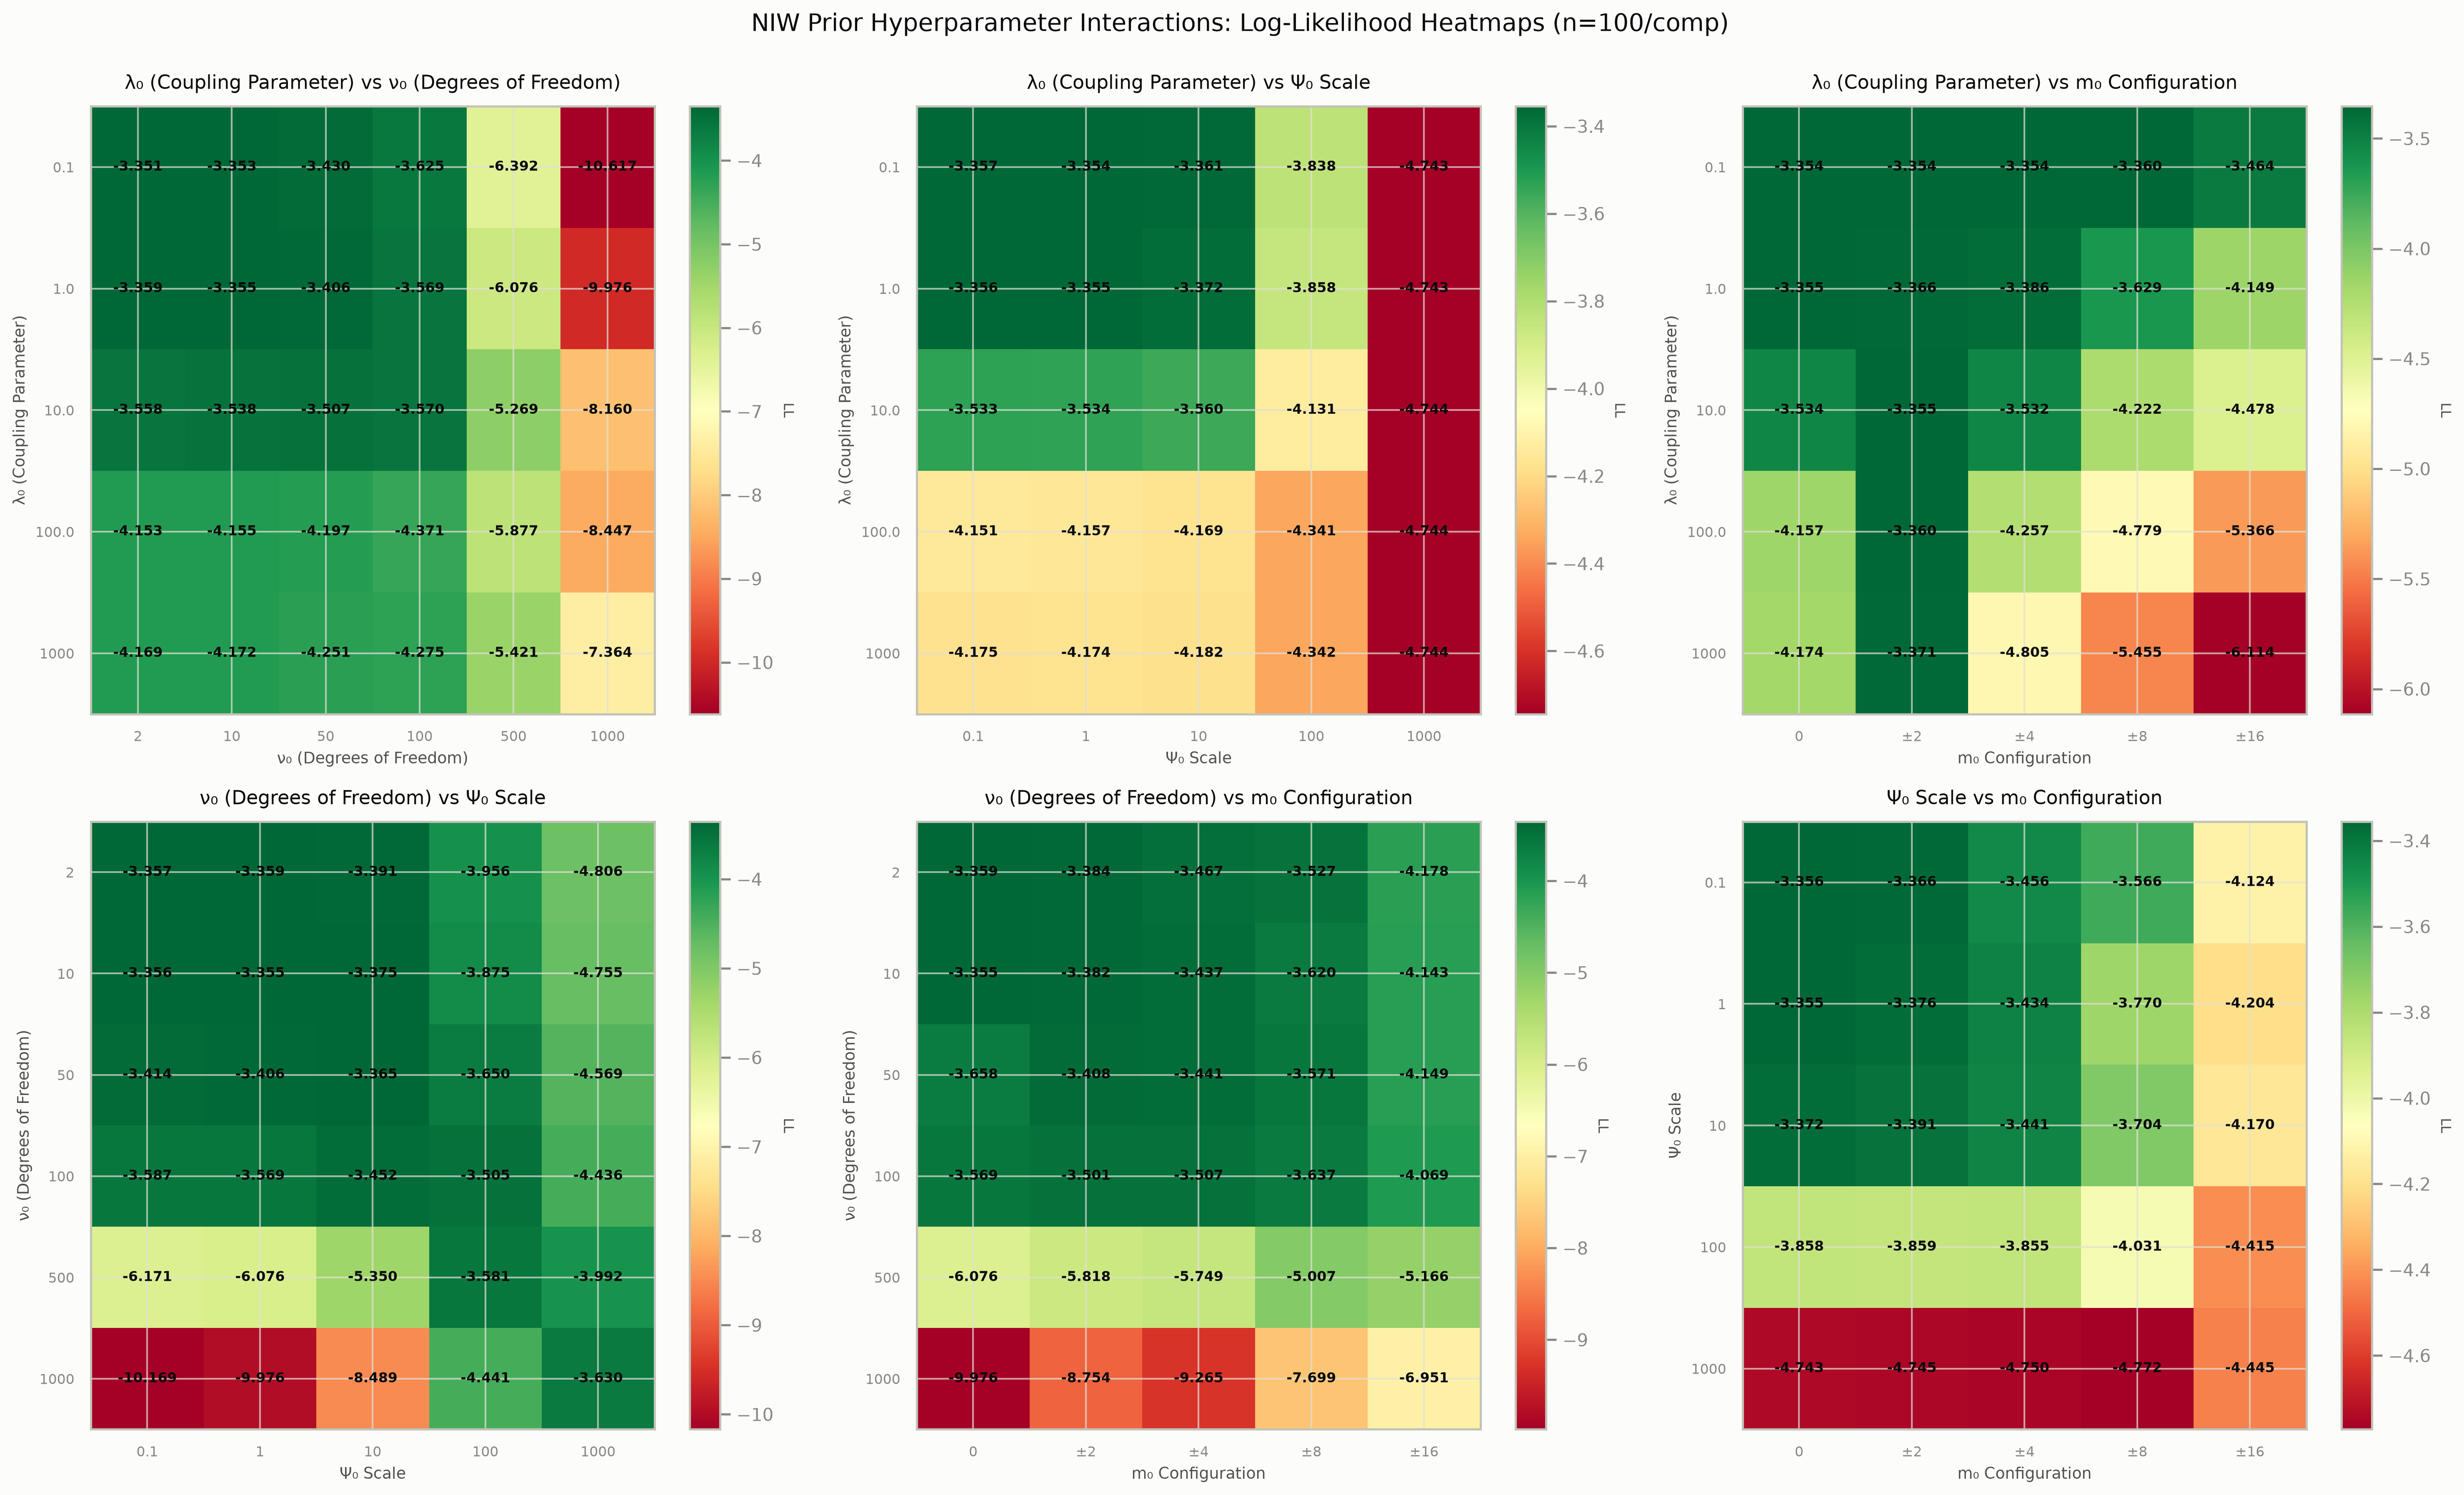

In [6]:
# Experiment 1: Equal sample sizes (n=100 per component)
n_samples_per_component = 100
X_list = []
for i, (mean, cov) in enumerate(zip(true_means, true_covs)):
    X_component = np.random.multivariate_normal(mean, cov, n_samples_per_component)
    X_list.append(X_component)

X = np.vstack(X_list)
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)

print(f"Experiment 1: {n_samples_per_component} samples per component")
analyze_niw_hyperparameters(X_tensor, n_components, n_features, device, title_suffix=" (n=100/comp)")

## What happens if we use 1000 instead of 100 points per component?

Experiment 2: 1000 samples per component


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


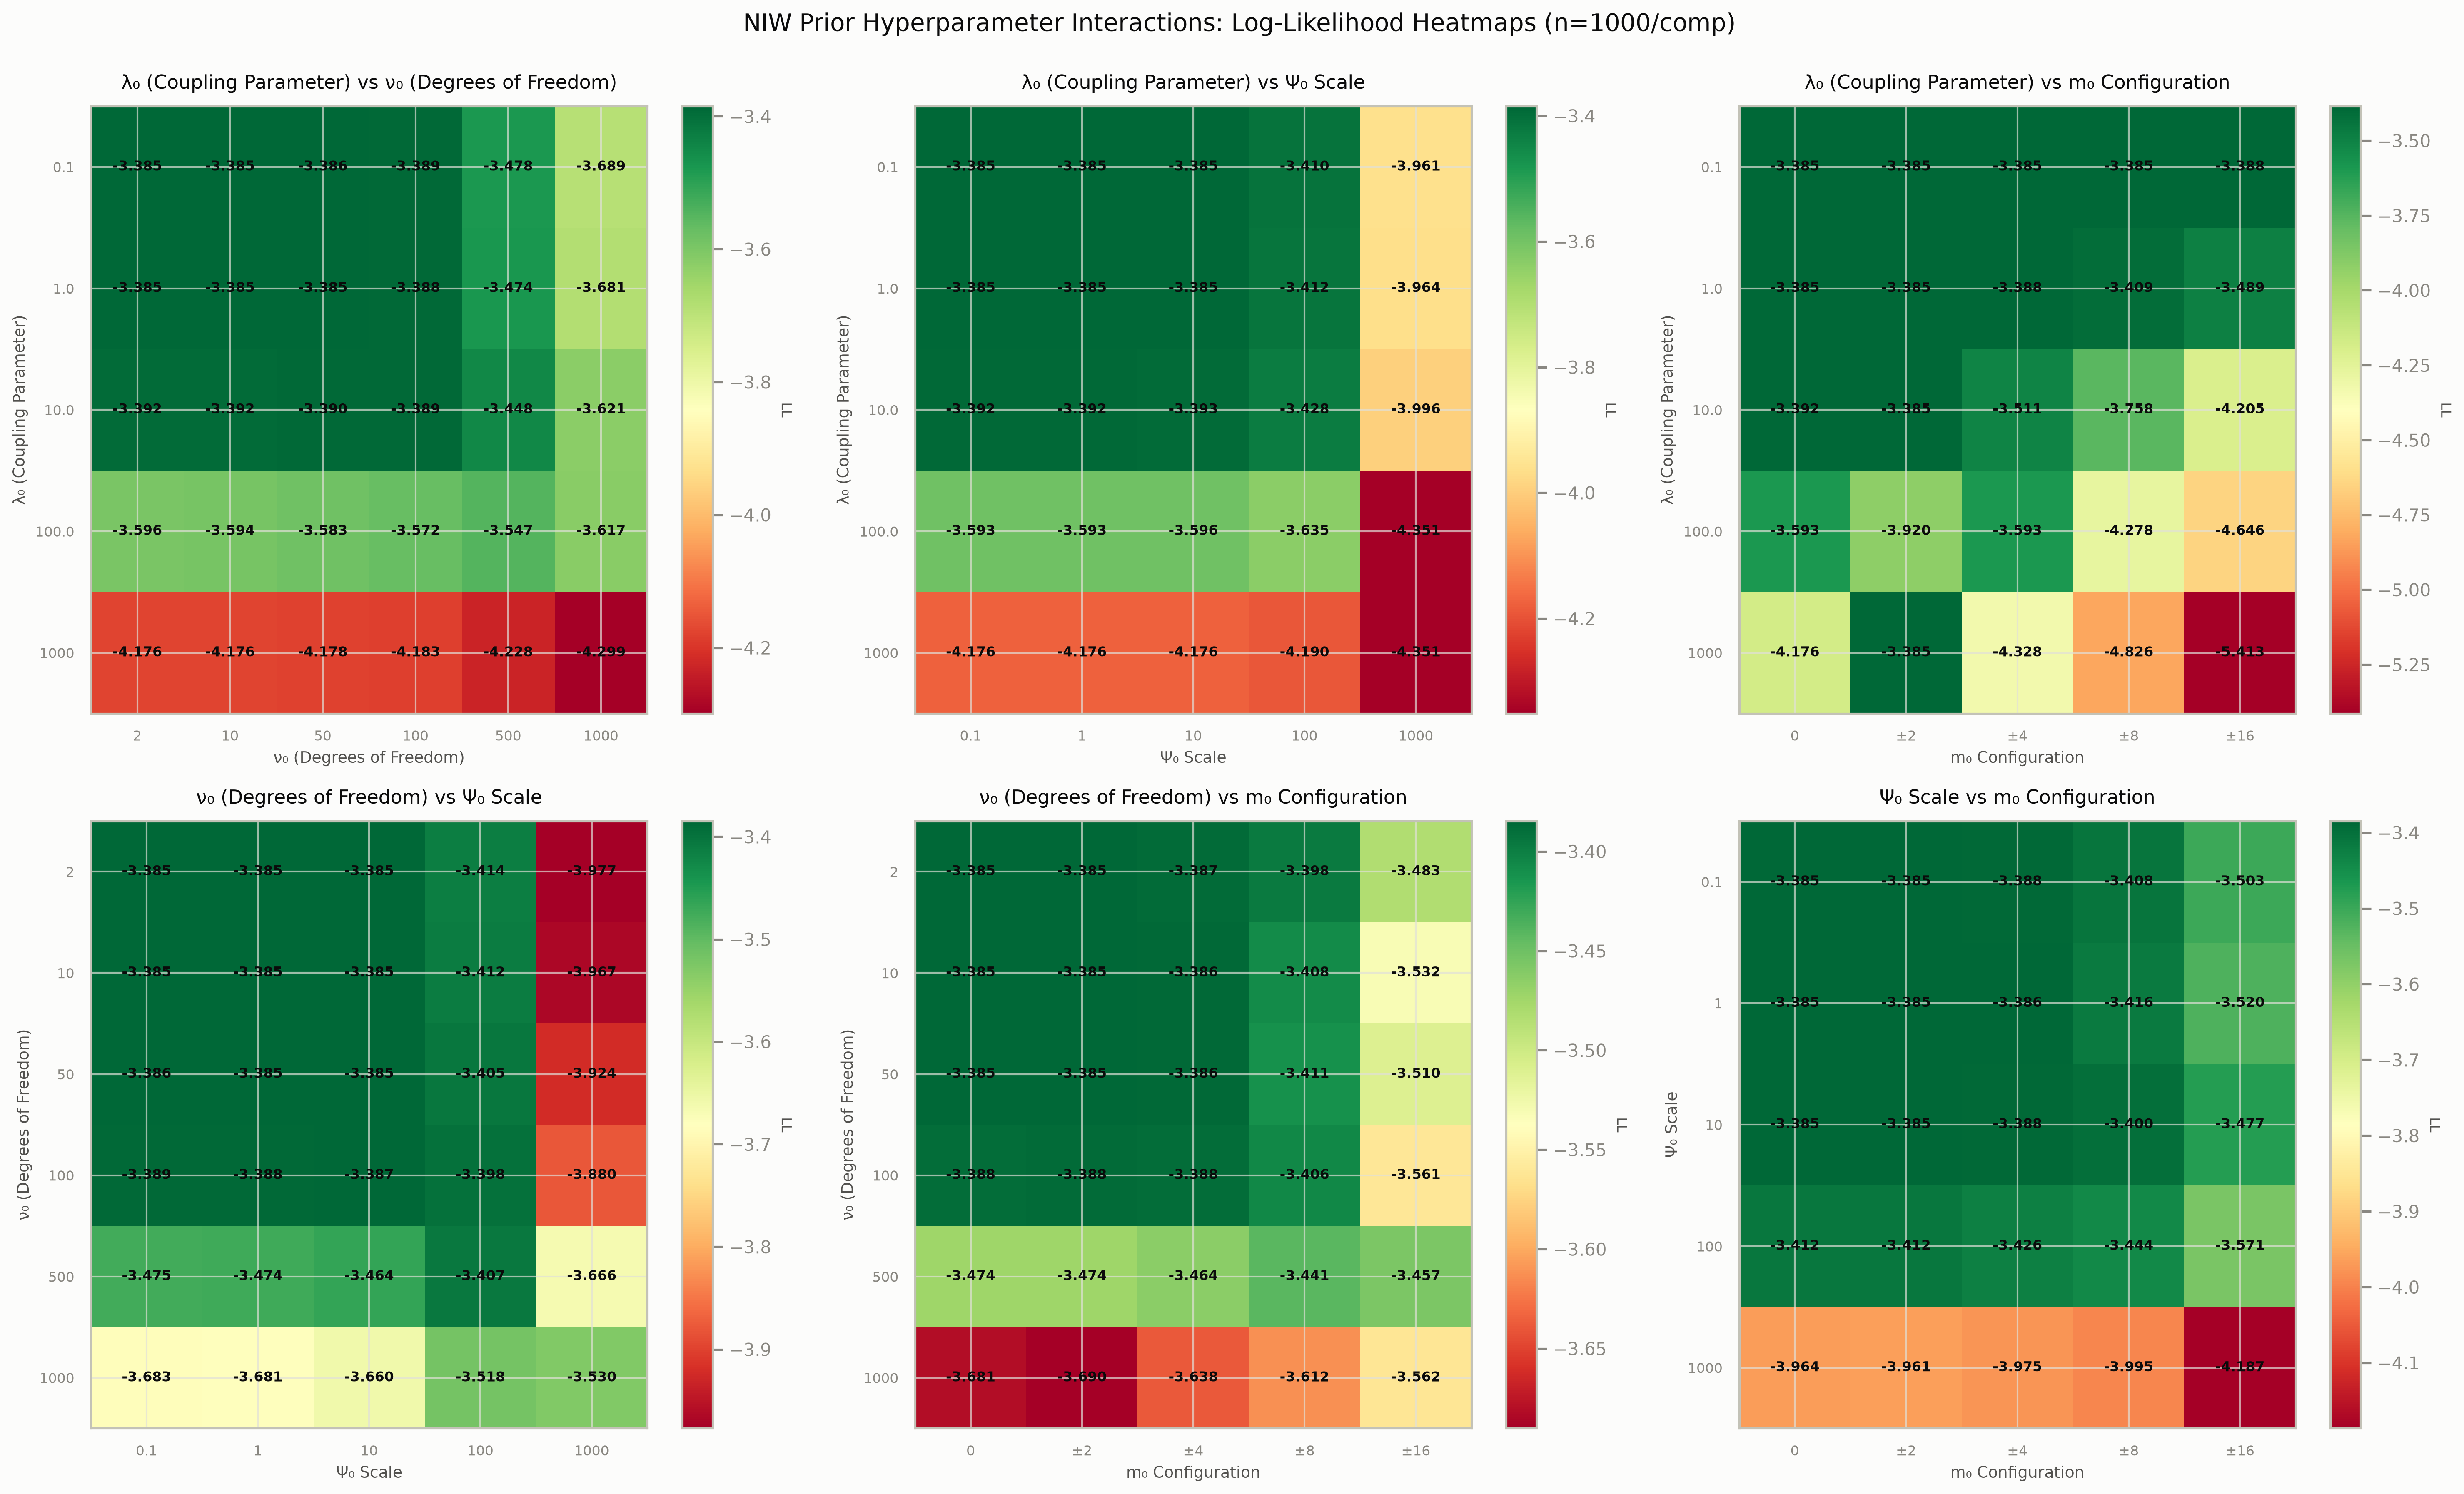

In [7]:
# Experiment 2: Equal sample sizes (n=1000 per component)
n_samples_per_component = 1000
X_list = []
for i, (mean, cov) in enumerate(zip(true_means, true_covs)):
    X_component = np.random.multivariate_normal(mean, cov, n_samples_per_component)
    X_list.append(X_component)

X = np.vstack(X_list)
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)

print(f"Experiment 2: {n_samples_per_component} samples per component")
analyze_niw_hyperparameters(X_tensor, n_components, n_features, device, title_suffix=" (n=1000/comp)")

## What happens if we use diffenrent number of points per component?

Experiment 3: [100, 500, 1000, 5000] samples per component (unequal)


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


/home/asp/Downloads/HeaDS/tgmm/tgmm/gmm.py:1250: UserWarning: Some cluster(s) have near-zero weight. This may indicate degenerate solutions.
  warnings.warn(


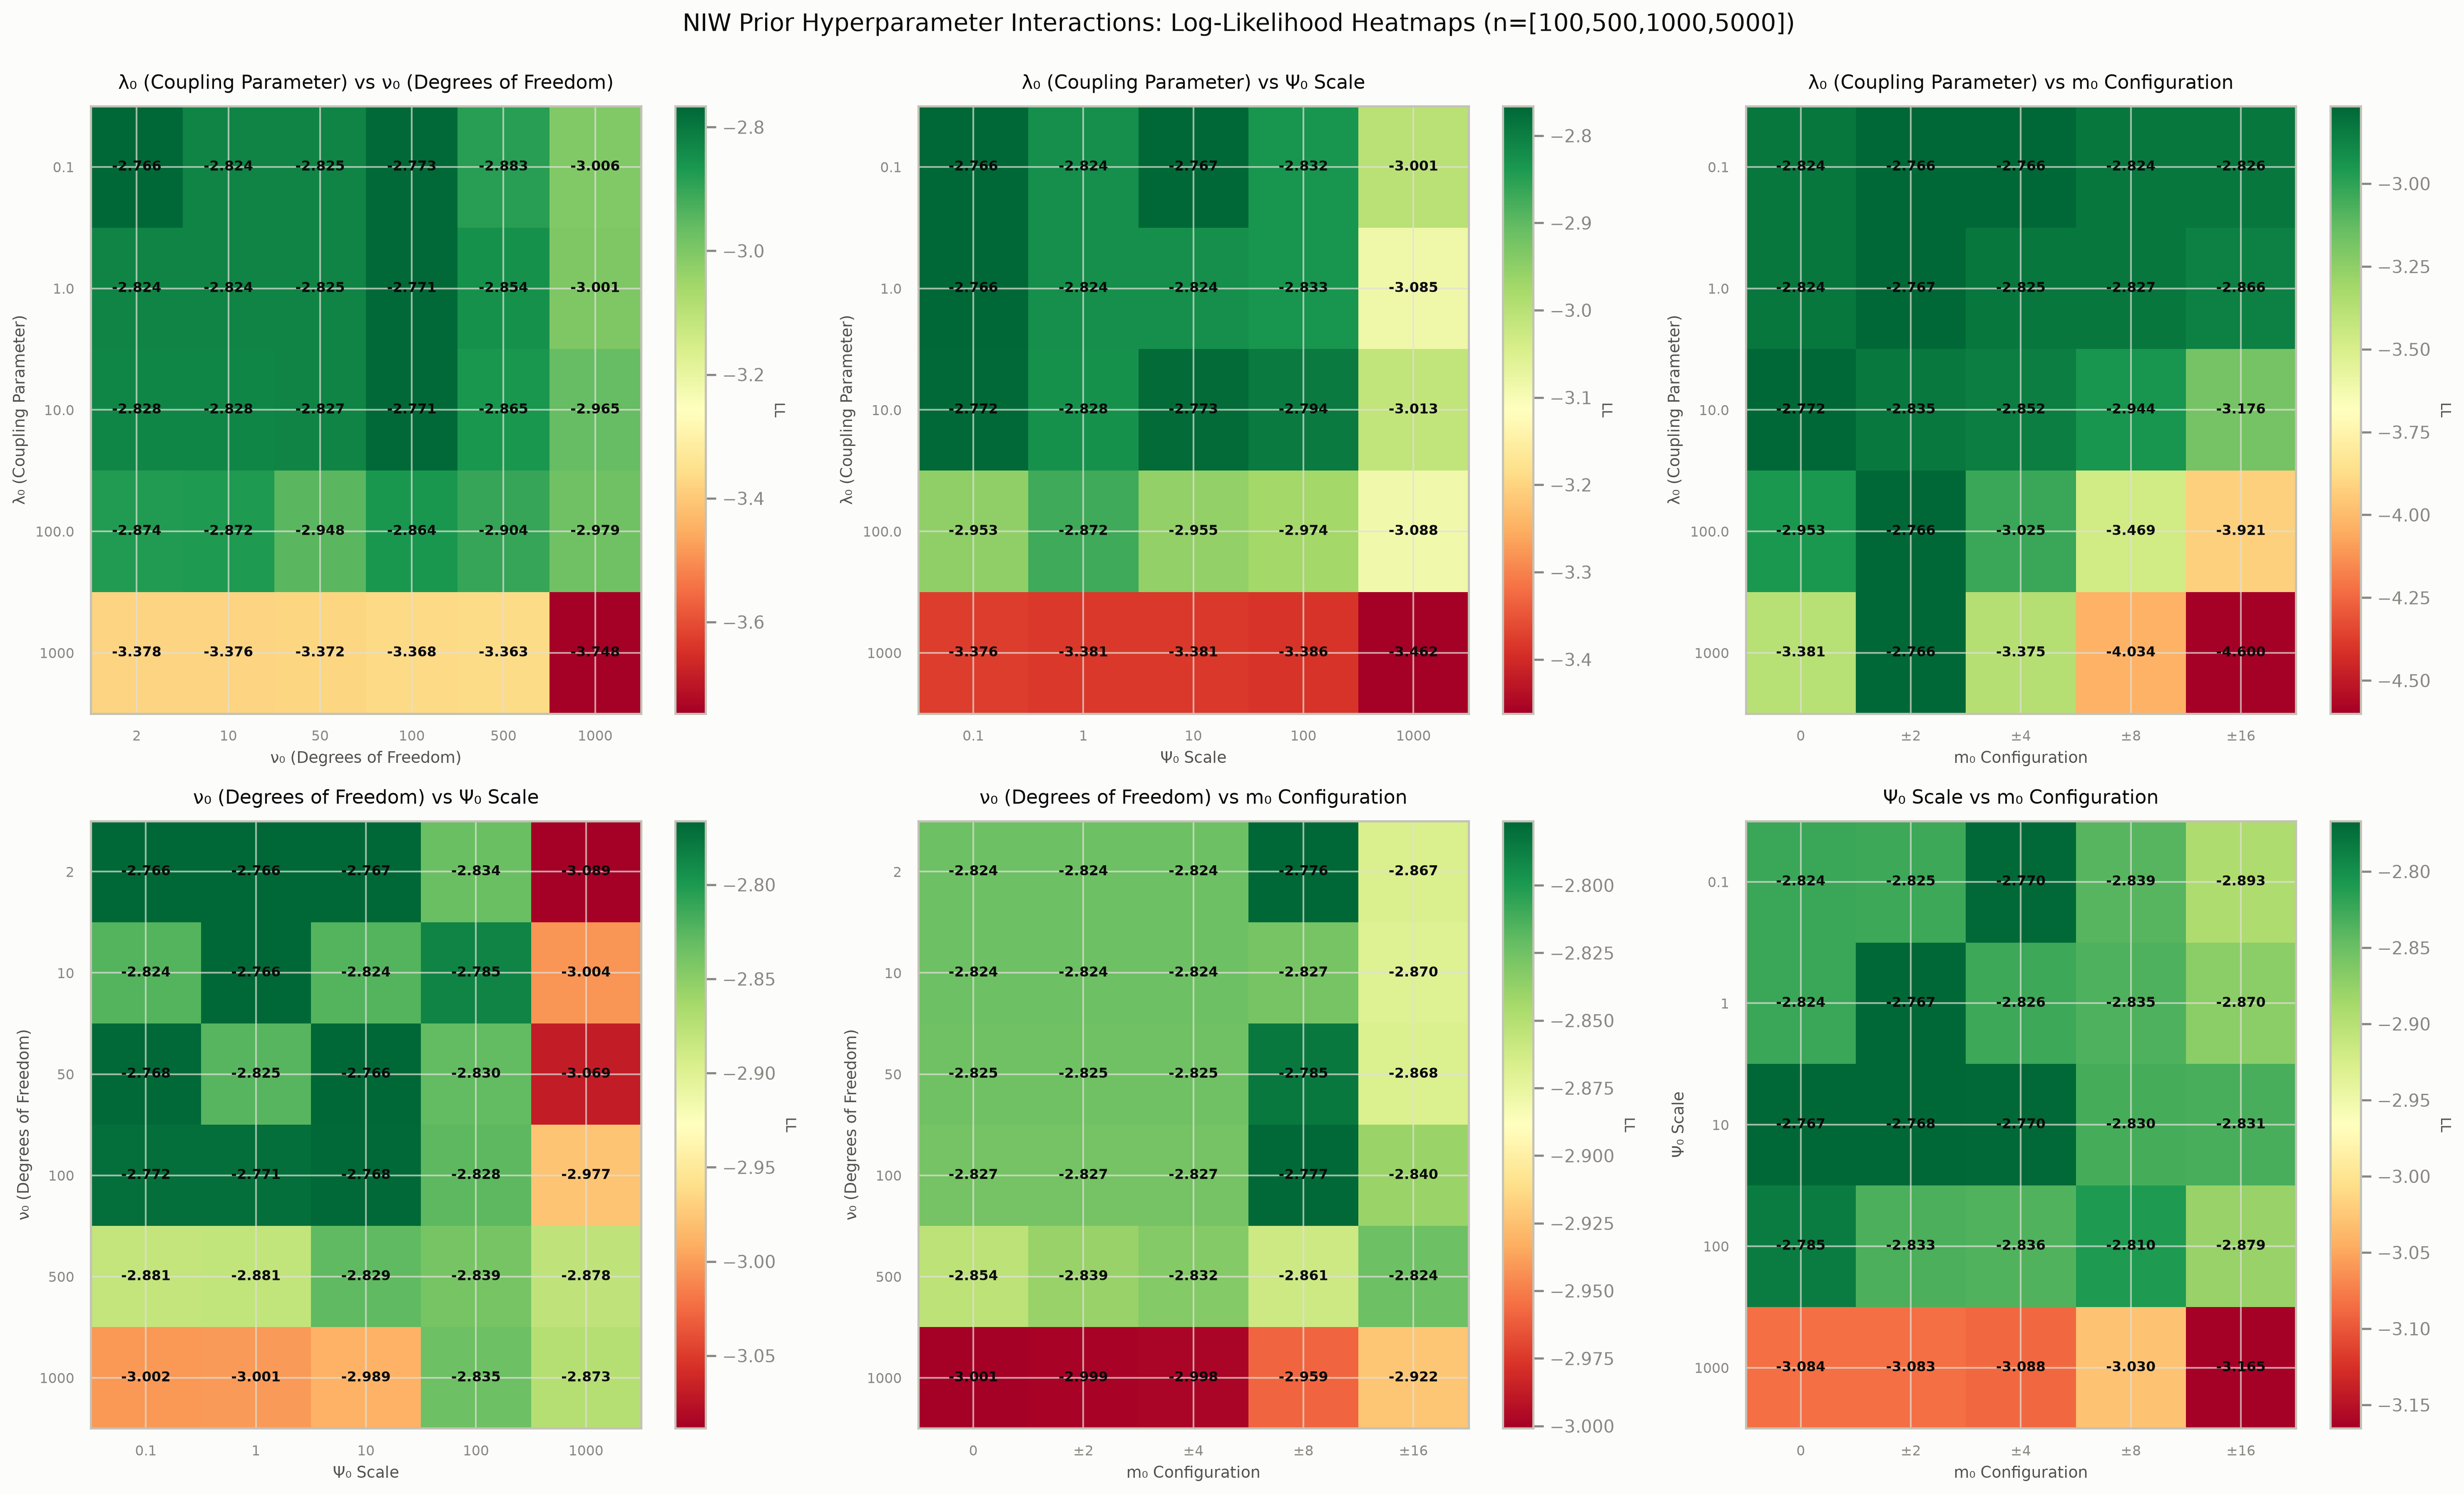

In [8]:
# Experiment 3: Unequal sample sizes per component
n_samples_per_component = [100, 500, 1000, 5000]
X_list = []
for i, (mean, cov, n_s) in enumerate(zip(true_means, true_covs, n_samples_per_component)):
    X_component = np.random.multivariate_normal(mean, cov, n_s)
    X_list.append(X_component)

X = np.vstack(X_list)
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)

print(f"Experiment 3: {n_samples_per_component} samples per component (unequal)")
analyze_niw_hyperparameters(X_tensor, n_components, n_features, device, 
                            title_suffix=" (n=[100,500,1000,5000])")